In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "product": ["A", "B", "C", "D", "E", "F", "F"],
    "price": [12000, 15000, np.nan, 18000, 20000, 999999, 999999],
    "stock": [10, 5, 8, np.nan, 20, 3, 3],
    "category": ["식품", "전자", "식품", "전자", np.nan, "식품", "식품"],
    "sold": [5, 2, 7, 1, 9, 3, 3]
})

df

,product,price,stock,category,sold
0,A,12000.0,10.0,식품,5
1,B,15000.0,5.0,전자,2
2,C,NaN,8.0,식품,7
3,D,18000.0,NaN,전자,1
4,E,20000.0,20.0,NaN,9
5,F,999999.0,3.0,식품,3
6,F,999999.0,3.0,식품,3


## 1번. 결측치와 중복 데이터 전처리
- 각 컬럼별 결측치 개수를 확인하시오.
- price의 결측치를 price의 중앙값으로 대체하시오.
- stock의 결측치를 stock의 평균값으로 대체하시오.
- category의 결측치를 category의 최빈값으로 대체하시오.
- 중복된 행을 제거하시오.
- 인덱스를 0부터 다시 설정하시오.

In [17]:
df.isna().sum()

product     0
price       1
stock       1
category    1
sold        0
dtype: int64

In [23]:
df["price"] = df["price"].fillna(df["price"].median())
df

,product,price,stock,category,sold
0,A,12000.0,10.0,식품,5
1,B,15000.0,5.0,전자,2
2,C,19000.0,8.0,식품,7
3,D,18000.0,NaN,전자,1
4,E,20000.0,20.0,NaN,9
5,F,999999.0,3.0,식품,3
6,F,999999.0,3.0,식품,3


In [25]:
df["stock"] = df["stock"].fillna(df["stock"].mean())
df

,product,price,stock,category,sold
0,A,12000.0,10.000000,식품,5
1,B,15000.0,5.000000,전자,2
2,C,19000.0,8.000000,식품,7
3,D,18000.0,8.166667,전자,1
4,E,20000.0,20.000000,NaN,9
5,F,999999.0,3.000000,식품,3
6,F,999999.0,3.000000,식품,3


In [35]:
df["category"] = df["category"].fillna(df["category"].mode()[0])
df

,product,price,stock,category,sold
0,A,12000.0,10.000000,식품,5
1,B,15000.0,5.000000,전자,2
2,C,19000.0,8.000000,식품,7
3,D,18000.0,8.166667,전자,1
4,E,20000.0,20.000000,식품,9
5,F,999999.0,3.000000,식품,3
6,F,999999.0,3.000000,식품,3


In [39]:
df.drop_duplicates()

,product,price,stock,category,sold
0,A,12000.0,10.000000,식품,5
1,B,15000.0,5.000000,전자,2
2,C,19000.0,8.000000,식품,7
3,D,18000.0,8.166667,전자,1
4,E,20000.0,20.000000,식품,9
5,F,999999.0,3.000000,식품,3


In [40]:
df.reset_index()

,index,product,price,stock,category,sold
0,0,A,12000.0,10.000000,식품,5
1,1,B,15000.0,5.000000,전자,2
2,2,C,19000.0,8.000000,식품,7
3,3,D,18000.0,8.166667,전자,1
4,4,E,20000.0,20.000000,식품,9
5,5,F,999999.0,3.000000,식품,3
6,6,F,999999.0,3.000000,식품,3


## 2번. 새로운 컬럼 생성 및 조건 필터링
- price * sold 값을 계산하여 revenue 컬럼을 생성하시오.
- revenue가 100000 이상인 데이터만 high_revenue에 저장하시오.
- high_revenue를 revenue가 높은 순서대로 정렬하시오.
- product, category, revenue 컬럼만 출력하시오.

In [43]:
df["revenue"] = df["price"] * df["sold"]
df

,product,price,stock,category,sold,revenue
0,A,12000.0,10.000000,식품,5,60000.0
1,B,15000.0,5.000000,전자,2,30000.0
2,C,19000.0,8.000000,식품,7,133000.0
3,D,18000.0,8.166667,전자,1,18000.0
4,E,20000.0,20.000000,식품,9,180000.0
5,F,999999.0,3.000000,식품,3,2999997.0
6,F,999999.0,3.000000,식품,3,2999997.0


In [49]:
mask = df["revenue"] >= 100000
high_revenue = df[mask]
high_revenue

,product,price,stock,category,sold,revenue
2,C,19000.0,8.0,식품,7,133000.0
4,E,20000.0,20.0,식품,9,180000.0
5,F,999999.0,3.0,식품,3,2999997.0
6,F,999999.0,3.0,식품,3,2999997.0


In [52]:
high_revenue.sort_values(by="revenue", ascending=False)

,product,price,stock,category,sold,revenue
6,F,999999.0,3.0,식품,3,2999997.0
5,F,999999.0,3.0,식품,3,2999997.0
4,E,20000.0,20.0,식품,9,180000.0
2,C,19000.0,8.0,식품,7,133000.0


In [57]:
df[["product", "category", "revenue"]]

,product,category,revenue
0,A,식품,60000.0
1,B,전자,30000.0
2,C,식품,133000.0
3,D,전자,18000.0
4,E,식품,180000.0
5,F,식품,2999997.0
6,F,식품,2999997.0


## 3번. 그룹별 데이터 분석
- category별 평균 price를 구하시오.
- category별 sold의 합계를 구하시오.
- category별 상품 개수를 구하시오.
- category별 price의 count, mean, min, max를 한 번에 출력하시오.

In [65]:
df.groupby("category")["price"].mean()

category
식품    410199.6
전자     16500.0
Name: price, dtype: float64

In [66]:
df.groupby("category")["sold"].sum()

category
식품    27
전자     3
Name: sold, dtype: int64

In [70]:
df.groupby("category")["product"].count()

category
식품    5
전자    2
Name: product, dtype: int64

In [73]:
df.groupby("category")["price"].agg(["count", "mean", "min", "max"])

,count,mean,min,max
category,,,,
식품,5,410199.6,12000.0,999999.0
전자,2,16500.0,15000.0,18000.0


## 4번. Seaborn을 이용한 데이터 시각화
df를 이용하여 다음 그래프를 작성하시오.
- price의 분포를 histplot으로 시각화하시오.
- category별 평균 price를 barplot으로 시각화하시오.
- category별 price 분포를 boxplot으로 시각화하시오.
- price와 sold의 관계를 scatterplot으로 시각화하시오.
- 각 그래프 출력 후 plt.show()를 사용하시오.

## 5번. IQR 이상치 처리 및 시각화
price 컬럼을 기준으로 다음 작업을 수행하시오.
- Q1을 구하시오.
- Q3를 구하시오.
- IQR을 구하시오.
- lower, upper를 계산하시오.
- 정상 범위의 데이터만 clean_df에 저장하시오.
- 이상치 제거 후 clean_df의 price를 boxplot으로 시각화하시오.

## 6번. 주가 데이터 EDA 및 시각화
close_df = pd.DataFrame({
    "TSLA": [250, 255, 248, 260, 270],
    "MSFT": [400, 405, 410, 408, 415],
    "KO": [60, 60.5, 60.2, 61, 61.3]
})

- 전일 대비 일별 수익률을 계산하여 returns_df에 저장하시오.
- 수익률 계산으로 발생한 결측치를 제거하시오.
- 각 종목의 평균 수익률을 구하시오.
- 각 종목의 수익률 표준편차를 구하시오.
- 종목 간 상관계수를 확인하시오.
- c lose_df의 종가 변화를 선그래프로 시각화하시오.
- returns_df의 상관계수를 seaborn heatmap으로 시각화하시오.
- heatmap 안에 상관계수 값이 표시되도록 하시오.

In [14]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [15]:
base_path = r"E:\kdf"
file_name = r"hr_employee_attrition.csv"

file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df

,Attrition,Age,Gender,MaritalStatus,Education,Department,JobRole,BusinessTravel,OverTime,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,YearsAtCompany,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,YearsSinceLastPromotion
0,Yes,41,Female,Single,2,Sales,Sales Executive,Travel_Rarely,Yes,1,5993,11,0,8,6,2,4,1,3,0
1,No,49,Male,Married,1,Research & Development,Research Scientist,Travel_Frequently,No,8,5130,23,1,10,10,3,2,3,4,1
2,Yes,37,Male,Single,2,Research & Development,Laboratory Technician,Travel_Rarely,Yes,2,2090,15,0,7,0,4,3,3,3,0
3,No,33,Female,Married,4,Research & Development,Research Scientist,Travel_Frequently,Yes,3,2909,11,0,8,8,4,3,3,3,3
4,No,27,Male,Married,1,Research & Development,Laboratory Technician,Travel_Rarely,No,2,3468,12,1,6,2,1,2,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,No,36,Male,Married,2,Research & Development,Laboratory Technician,Travel_Frequently,No,23,2571,17,1,17,5,3,4,3,3,0
1466,No,39,Male,Married,1,Research & Development,Healthcare Representative,Travel_Rarely,No,6,9991,15,1,9,7,4,1,3,3,1
1467,No,27,Male,Married,3,Research & Development,Manufacturing Director,Travel_Rarely,Yes,4,6142,20,1,6,6,2,2,3,4,0
1468,No,49,Male,Married,3,Sales,Sales Executive,Travel_Frequently,No,2,5390,14,0,17,9,4,2,2,3,0


In [16]:
df[df["MonthlyIncome"] == 19999]

,Attrition,Age,Gender,MaritalStatus,Education,Department,JobRole,BusinessTravel,OverTime,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,YearsAtCompany,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,YearsSinceLastPromotion
190,No,52,Male,Married,4,Research & Development,Manager,Travel_Rarely,No,1,19999,14,1,34,33,3,3,3,3,11


## 야근(OverTime)을 하는 직원과 야근을 하지 않는 직원의 이직률 차이가 얼마나 나는지 비교하고 결과를 서술하세요.
- 범주형 vs 범주형 데이터

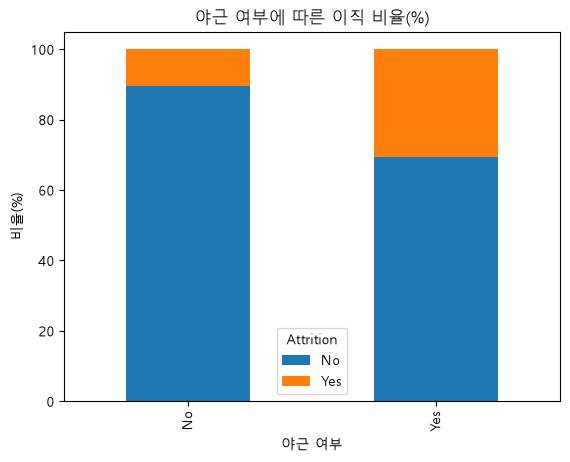

In [38]:
overtime_attrition = pd.crosstab(df["OverTime"], df["Attrition"], normalize="index") * 100

overtime_attrition.plot(kind="bar", stacked=True)
plt.title("야근 여부에 따른 이직 비율(%)")
plt.xlabel("야근 여부")
plt.ylabel("비율(%)")
plt.show()